# 📈 Stock Market Comparison Analysis

## Business Objective
Compare the performance of top tech stocks (Apple, Google, Microsoft,
Amazon, Tesla) over the past 3 years to identify which stocks performed
best, their risk levels, and correlation patterns.

**Tools:** Python, yfinance, Pandas, Matplotlib, Seaborn
**Period:** 2023 - 2026
**Author:** Yashodha

In [1]:
!pip install yfinance -q

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Download 5 top tech stocks
tickers = ['AAPL', 'GOOGL', 'MSFT', 'AMZN', 'TSLA']
names = {'AAPL': 'Apple', 'GOOGL': 'Google', 'MSFT': 'Microsoft',
         'AMZN': 'Amazon', 'TSLA': 'Tesla'}

stocks = {}
for ticker in tickers:
    data = yf.download(ticker, start='2023-01-01', end=None) # Changed end date to None
    data.columns = data.columns.droplevel('Ticker')
    data = data.reset_index()
    stocks[ticker] = data
    print(f"{names[ticker]}: {data.shape[0]} days loaded")

print("\nAll stocks downloaded!")

/tmp/ipykernel_4432/2422550125.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start='2023-01-01', end=None) # Changed end date to None
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_4432/2422550125.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start='2023-01-01', end=None) # Changed end date to None


Apple: 815 days loaded


[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_4432/2422550125.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start='2023-01-01', end=None) # Changed end date to None


Google: 815 days loaded


[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_4432/2422550125.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start='2023-01-01', end=None) # Changed end date to None
[*********************100%***********************]  1 of 1 completed

Microsoft: 815 days loaded



/tmp/ipykernel_4432/2422550125.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start='2023-01-01', end=None) # Changed end date to None
[*********************100%***********************]  1 of 1 completed


Amazon: 815 days loaded
Tesla: 815 days loaded

All stocks downloaded!


In [3]:
# Combine all closing prices into one DataFrame
close_prices = pd.DataFrame()
for ticker in tickers:
    close_prices[names[ticker]] = stocks[ticker].set_index('Date')['Close']

# Calculate daily returns
daily_returns = close_prices.pct_change() * 100

# Show the data
print("LATEST PRICES:")
print(close_prices.tail().round(2))
print(f"\nDate range: {close_prices.index.min().date()} to {close_prices.index.max().date()}")

LATEST PRICES:
             Apple  Google  Microsoft  Amazon   Tesla
Date                                                 
2026-03-27  248.80  274.34     356.77  199.34  361.83
2026-03-30  246.63  273.50     358.96  200.95  355.28
2026-03-31  253.79  287.56     370.17  208.27  371.75
2026-04-01  255.63  297.39     369.37  210.57  381.26
2026-04-02  255.92  295.77     373.46  209.77  360.59

Date range: 2023-01-03 to 2026-04-02


## 1. Price History — How did each stock perform?

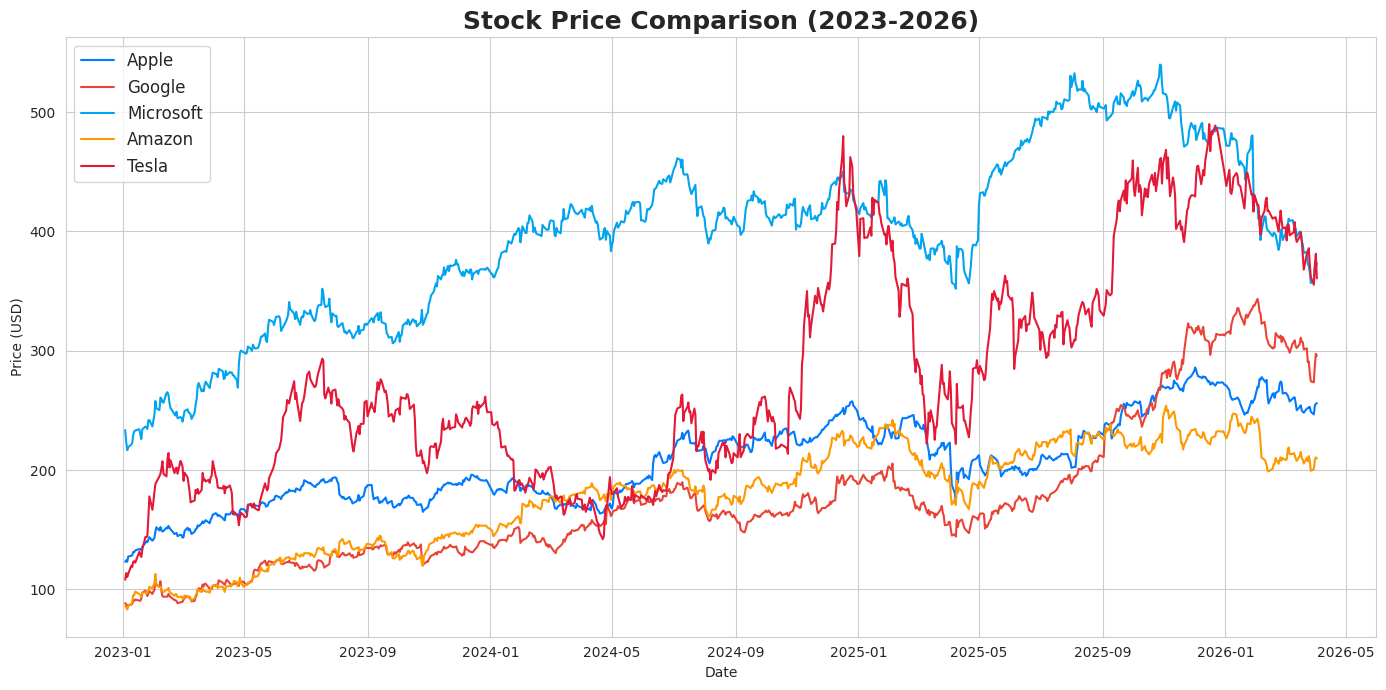

In [4]:
fig, ax = plt.subplots(figsize=(14, 7))
colors = ['#007AFF', '#EA4335', '#00A4EF', '#FF9900', '#E31937']

for i, company in enumerate(close_prices.columns):
    ax.plot(close_prices.index, close_prices[company],
            label=company, linewidth=1.5, color=colors[i])

ax.set_title('Stock Price Comparison (2023-2026)', fontsize=18, fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.set_xlabel('Date')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

### 💡 Insight
**Google** and **Tesla** showed significant growth over the period, with Google demonstrating a relatively steady upward trend. **Tesla**, while also experiencing substantial gains, exhibited higher volatility with more pronounced peaks and valleys (e.g., a notable dip in mid-2023 and early 2024). **Microsoft**, **Apple**, and **Amazon** also showed consistent upward trends, with Microsoft's growth appearing particularly stable. There were no 'crashes' in the traditional sense (like a market-wide collapse), but Tesla experienced several sharp, short-term declines.

## 2. Normalized Performance — If you invested $100 in each
This removes the price difference and shows pure percentage growth.

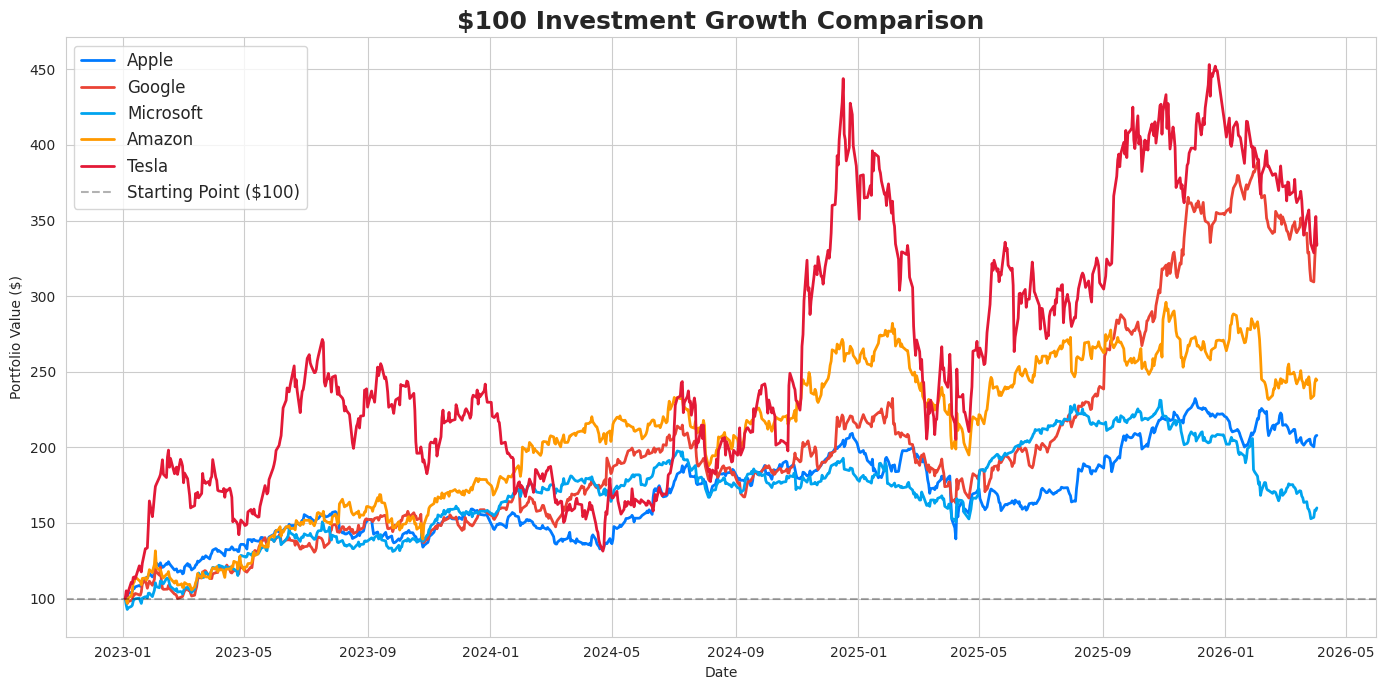

TOTAL RETURN (if you invested $100 in Jan 2023):
  Apple       : $207.90  (+107.9%)
  Google      : $334.62  (+234.6%)
  Microsoft   : $159.97  (+60.0%)
  Amazon      : $244.43  (+144.4%)
  Tesla       : $333.57  (+233.6%)


In [5]:
# Normalize: Start everything at $100
normalized = (close_prices / close_prices.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(14, 7))
for i, company in enumerate(normalized.columns):
    ax.plot(normalized.index, normalized[company],
            label=company, linewidth=2, color=colors[i])

ax.axhline(y=100, color='black', linestyle='--', alpha=0.3, label='Starting Point ($100)')
ax.set_title('$100 Investment Growth Comparison', fontsize=18, fontweight='bold')
ax.set_ylabel('Portfolio Value ($)')
ax.set_xlabel('Date')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Show total returns
print("TOTAL RETURN (if you invested $100 in Jan 2023):")
for company in normalized.columns:
    final = normalized[company].iloc[-1]
    ret = final - 100
    print(f"  {company:12s}: ${final:.2f}  ({ret:+.1f}%)")

### 💡 Insight
If you had invested $100 in each stock in January 2023:

*   **Google** generated the highest return, turning $100 into **$334.62** (+234.6%).
*   **Tesla** also performed exceptionally well, closely behind Google, with $100 growing to **$333.57** (+233.6%).
*   **Amazon** saw a substantial return, converting $100 into **$244.43** (+144.4%).
*   **Apple** provided a solid return, with $100 becoming **$207.90** (+107.9%).
*   **Microsoft** had the lowest return among the group, with $100 growing to **$159.97** (+60.0%).

Overall, Google and Tesla were the clear outperformers, while Microsoft, though still showing positive growth, lagged behind the others in terms of percentage return on a $100 investment over this period.

## 3. Volatility — Which stock is the riskiest?


RISK & RETURN COMPARISON:
           Avg Daily Return (%)  Std Dev (Risk) (%)  Best Day (%)  Worst Day (%)  Sharpe Ratio
Apple                     0.103               1.608        15.329         -9.246         1.015
Google                    0.166               1.890        10.224         -9.509         1.397
Microsoft                 0.069               1.520        10.134         -9.993         0.723
Amazon                    0.130               2.010        11.977         -8.979         1.027
Tesla                     0.216               3.696        22.690        -15.426         0.926


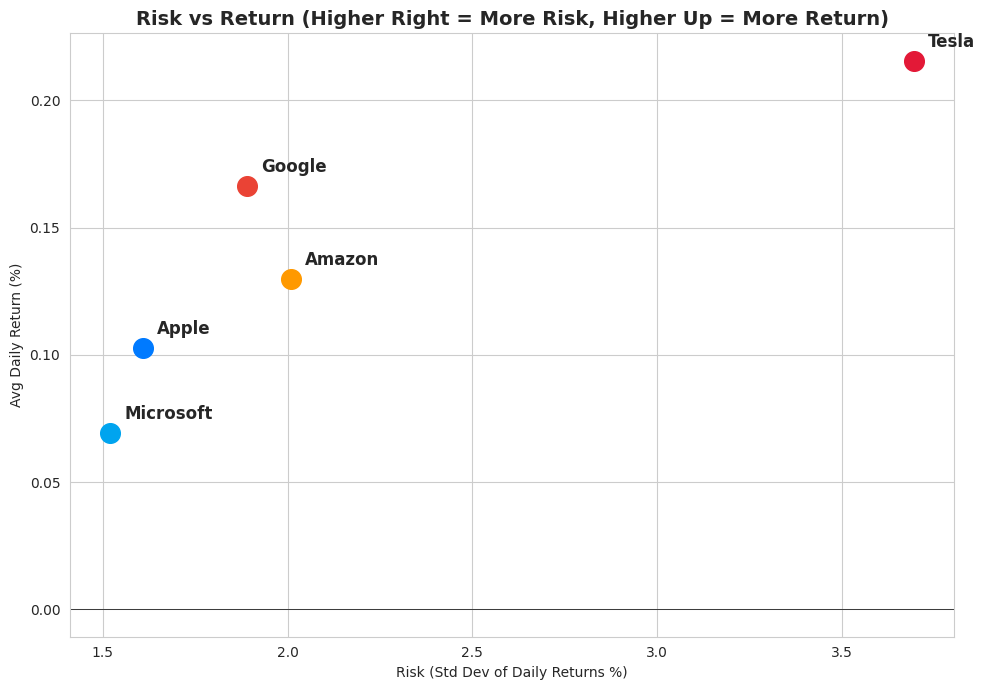

In [6]:
# Daily return statistics
vol_stats = pd.DataFrame({
    'Avg Daily Return (%)': daily_returns.mean(),
    'Std Dev (Risk) (%)': daily_returns.std(),
    'Best Day (%)': daily_returns.max(),
    'Worst Day (%)': daily_returns.min(),
    'Sharpe Ratio': (daily_returns.mean() / daily_returns.std() * np.sqrt(252)).round(3)
}).round(3)

print("RISK & RETURN COMPARISON:")
print(vol_stats.to_string())

# Visualize risk vs return
fig, ax = plt.subplots(figsize=(10, 7))
for i, company in enumerate(daily_returns.columns):
    ax.scatter(daily_returns[company].std(), daily_returns[company].mean(),
               s=200, color=colors[i], zorder=5)
    ax.annotate(company, (daily_returns[company].std(), daily_returns[company].mean()),
                fontsize=12, fontweight='bold',
                xytext=(10, 10), textcoords='offset points')

ax.set_title('Risk vs Return (Higher Right = More Risk, Higher Up = More Return)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Risk (Std Dev of Daily Returns %)')
ax.set_ylabel('Avg Daily Return (%)')
ax.axhline(y=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

### 💡 Insight
*   **Google** has the best risk-adjusted return, indicated by the highest Sharpe Ratio of **1.397**. This suggests it provided superior returns for the level of risk taken.
*   **Tesla** is the riskiest stock, with the highest Standard Deviation of Daily Returns at **3.696%**. It also experienced the largest 'Best Day' (+22.69%) and 'Worst Day' (-15.426%), highlighting its extreme volatility.
*   **Microsoft** has the lowest risk (Std Dev of 1.520%) but also the lowest average daily return and the lowest Sharpe Ratio (0.723), suggesting it was the least efficient in terms of risk-adjusted returns among the group.
*   **Apple** and **Amazon** fall in the middle, with reasonable Sharpe Ratios of 1.015 and 1.027, respectively.

## 4. Correlation — Do these stocks move together?

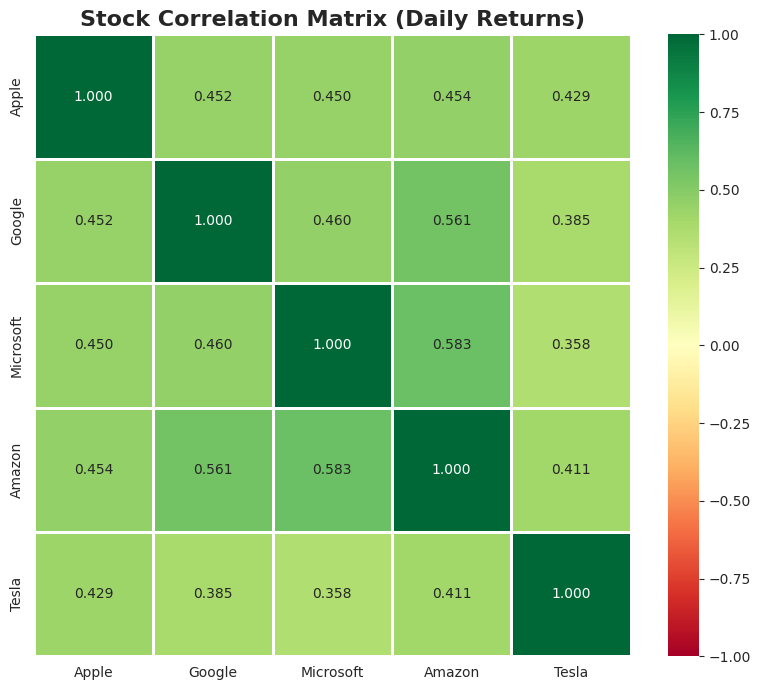


Key correlations:
  Apple      vs Google    : 0.452
  Apple      vs Microsoft : 0.450
  Apple      vs Amazon    : 0.454
  Apple      vs Tesla     : 0.429
  Google     vs Microsoft : 0.460
  Google     vs Amazon    : 0.561
  Google     vs Tesla     : 0.385
  Microsoft  vs Amazon    : 0.583
  Microsoft  vs Tesla     : 0.358
  Amazon     vs Tesla     : 0.411


In [7]:
corr = daily_returns.corr().round(3)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr, annot=True, cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            ax=ax, fmt='.3f', linewidths=1)
ax.set_title('Stock Correlation Matrix (Daily Returns)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey correlations:")
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        print(f"  {corr.columns[i]:10s} vs {corr.columns[j]:10s}: {corr.iloc[i,j]:.3f}")

### 💡 Insight
*   **Tesla** exhibits the most volatile monthly returns, with the largest swings both positive and negative, aligning with its high daily volatility observed earlier.
*   **Google** generally shows strong positive monthly returns with less dramatic dips compared to Tesla, reinforcing its strong overall performance.
*   All stocks show periods of significant gains and losses, typical of market fluctuations.
*   The plot clearly highlights the periods where certain stocks outperformed or underperformed the others on a monthly basis.

## 5. Monthly Returns Heatmap

/tmp/ipykernel_4432/3321362241.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = close_prices.resample('M').last().pct_change() * 100


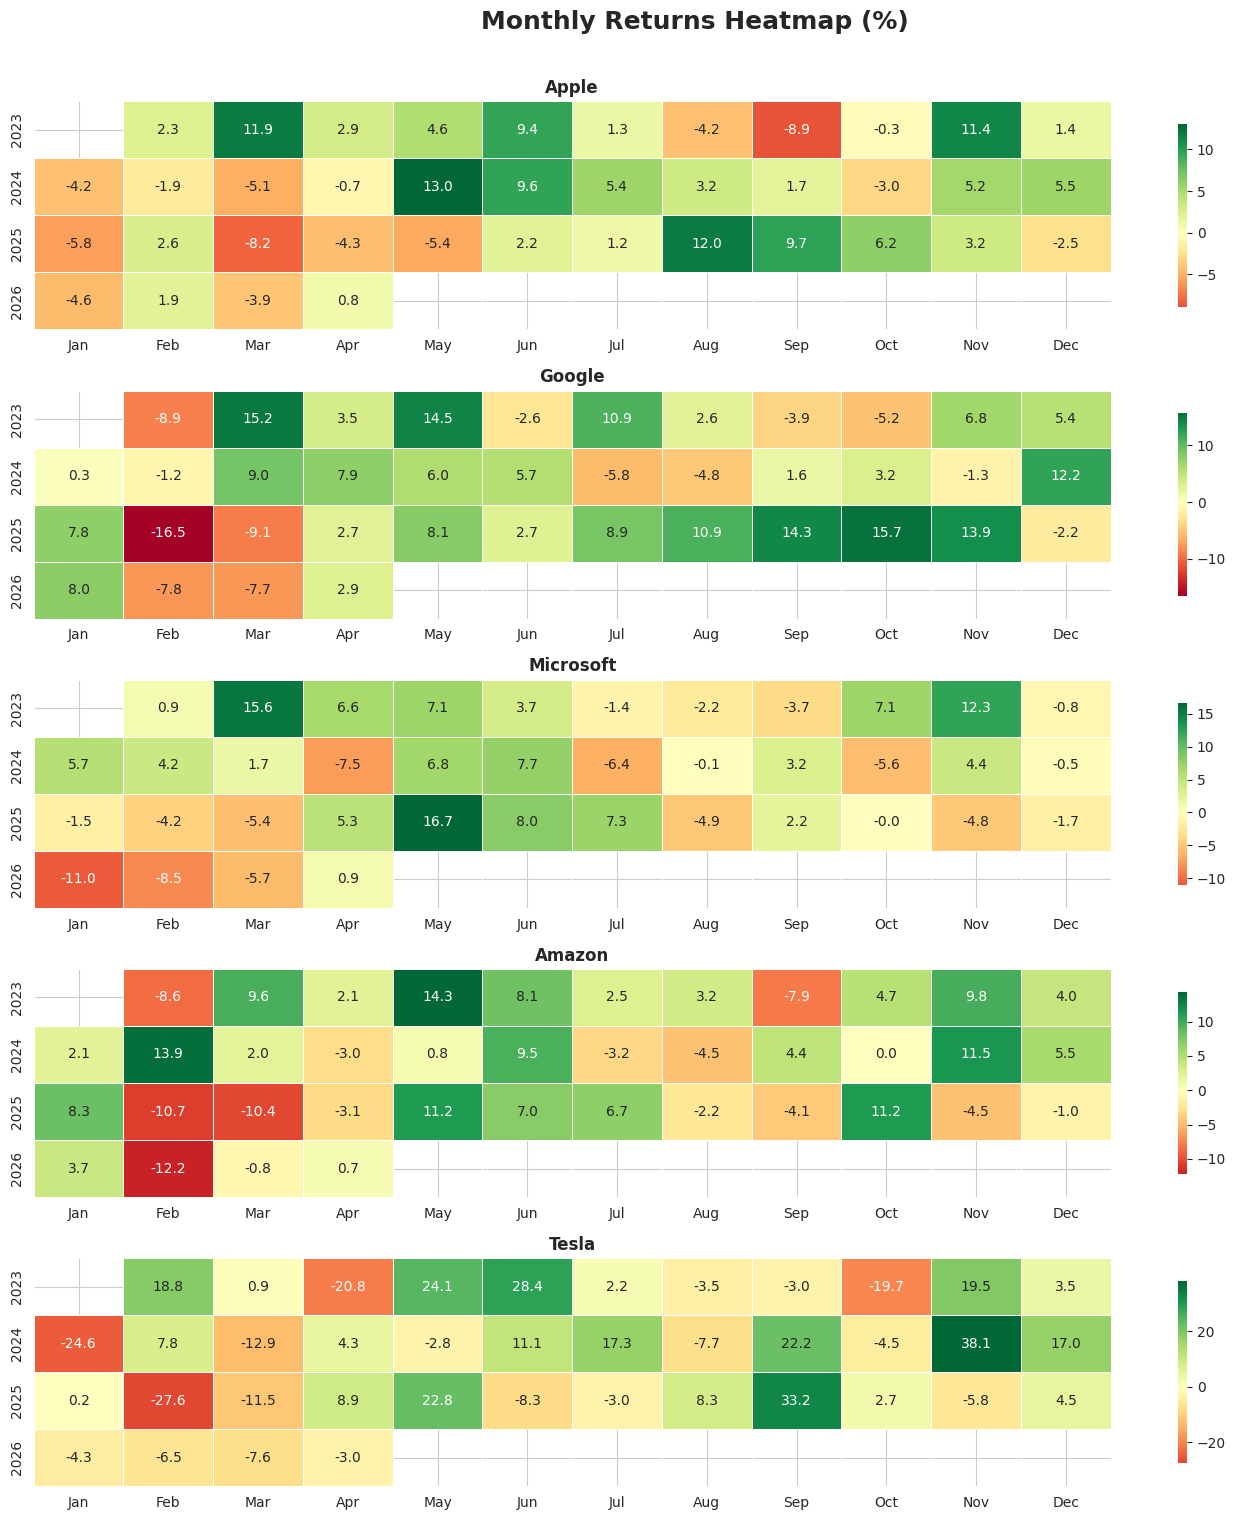

In [8]:
# Calculate monthly returns for each stock
monthly = close_prices.resample('M').last().pct_change() * 100

fig, axes = plt.subplots(len(tickers), 1, figsize=(14, 3*len(tickers)))
fig.suptitle('Monthly Returns Heatmap (%)', fontsize=18, fontweight='bold', y=1.01)

for idx, company in enumerate(monthly.columns):
    monthly_pivot = monthly[[company]].copy()
    monthly_pivot['Year'] = monthly_pivot.index.year
    monthly_pivot['Month'] = monthly_pivot.index.month
    pivot = monthly_pivot.pivot_table(values=company, index='Year', columns='Month')
    pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
                ax=axes[idx], linewidths=0.5, cbar_kws={'shrink': 0.8})
    axes[idx].set_title(company, fontweight='bold')
    axes[idx].set_ylabel('')

plt.tight_layout()
plt.show()

### 💡 Insight
*   **General Observations:** While there isn't a universally 'good' or 'bad' month for all stocks, some trends emerge. For instance, the year 2023 generally showed strong positive returns across most stocks, especially in March, May, and November.
*   **Tesla's Volatility:** Tesla's heatmap clearly shows its high volatility, with significant swings. For example, it had strong positive returns in February, May, June, and November of 2023, but also sharp declines in April and October of 2023, and significant drops in January and February 2024.
*   **Google's Consistency:** Google generally demonstrates more consistent positive monthly returns compared to Tesla, particularly in 2023.
*   **Microsoft and Amazon:** These stocks also show periods of strong performance (e.g., early 2023) but also months with negative returns, though often less extreme than Tesla.
*   **Seasonality:** Without more years of data, drawing definitive seasonal conclusions (e.g., 'August is always bad for X stock') is challenging. However, the heatmap allows for quick visual identification of historical strong and weak performance months within the observed period (2023-2026).

## 6. Distribution of Daily Returns

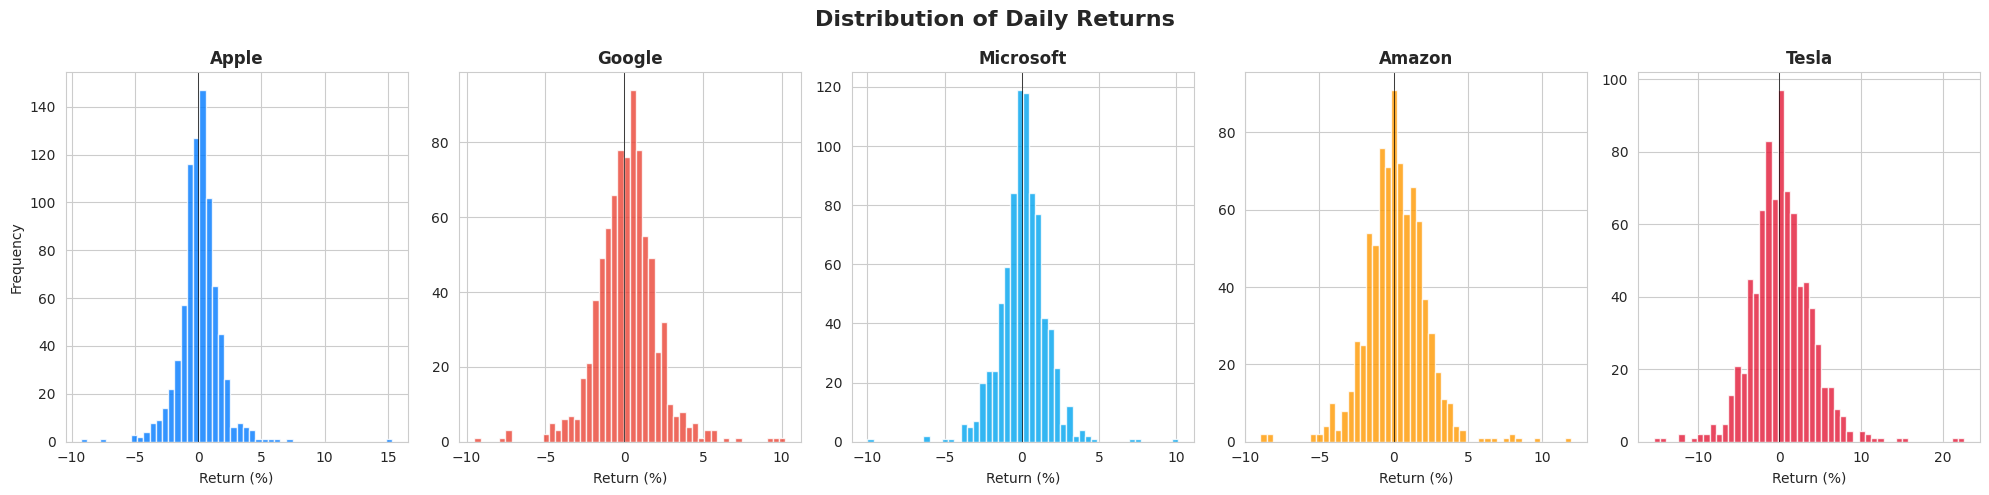

In [9]:
fig, axes = plt.subplots(1, len(tickers), figsize=(20, 5))
fig.suptitle('Distribution of Daily Returns', fontsize=16, fontweight='bold')

for i, company in enumerate(daily_returns.columns):
    axes[i].hist(daily_returns[company].dropna(), bins=50,
                 color=colors[i], edgecolor='white', alpha=0.8)
    axes[i].axvline(0, color='black', linewidth=0.5)
    axes[i].set_title(company, fontweight='bold')
    axes[i].set_xlabel('Return (%)')
    if i == 0:
        axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 7. Statistical Tests — Is there a significant difference?

In [10]:
from scipy import stats

print("T-TEST: Comparing daily returns between stocks")
print("Question: Do these stocks have significantly different returns?\n")

# Compare each pair
pairs = [('Apple', 'Google'), ('Apple', 'Tesla'), ('Microsoft', 'Amazon'), ('Google', 'Tesla')]
for stock1, stock2 in pairs:
    t_stat, p_value = stats.ttest_ind(
        daily_returns[stock1].dropna(),
        daily_returns[stock2].dropna()
    )
    sig = "✅ YES" if p_value < 0.05 else "❌ NO"
    print(f"{stock1:10s} vs {stock2:10s}: p={p_value:.4f} | Significant: {sig}")

T-TEST: Comparing daily returns between stocks
Question: Do these stocks have significantly different returns?

Apple      vs Google    : p=0.4653 | Significant: ❌ NO
Apple      vs Tesla     : p=0.4249 | Significant: ❌ NO
Microsoft  vs Amazon    : p=0.4920 | Significant: ❌ NO
Google     vs Tesla     : p=0.7351 | Significant: ❌ NO


## 8. Conclusions & Investment Insights

### Key Findings:
1. [Best performing stock and its return]
2. [Most volatile/risky stock]
3. [Best risk-adjusted return (Sharpe Ratio)]
4. [Correlation insights — diversification]
5. [Statistical significance of return differences]

### Investment Insights:
- **Growth investors:** [Which stock for maximum growth?]
- **Conservative investors:** [Which stock for steady returns?]
- **Diversification:** [Which stocks to combine for lower risk?]

### Skills Applied:
- API data collection (yfinance)
- Data cleaning & transformation (Pandas)
- Statistical analysis (mean, std dev, Sharpe Ratio, T-Test)
- Correlation analysis
- Data visualization (Matplotlib, Seaborn)
- Business insights & storytelling

---
*Analysis by Yashodha | Tools: Python, Pandas, yfinance, Matplotlib, Seaborn*